In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import glob
import ast

In [2]:
clf_model_path =  "../l2d_models/full_dataset_Polypgen_20250421_222611/deferral_classification_model.pkl"
reg_model_path = "../l2d_models/full_dataset_Polypgen_20250421_222611/deferral_regression_model.pkl"
feature_csv_dir = "../media/video_features"


In [3]:
all_feature_csv = os.path.join(feature_csv_dir, "*.csv")
all_feature_df = pd.concat((pd.read_csv(f) for f in glob.glob(all_feature_csv)), ignore_index=True)

all_feature_df

,video,frame,X,y,y_tmp,mean_future_iou_c,mean_future_iou_u
0,seq18,1,"[np.float64(0.8296732214737793), -5.6392202377...",1,0.538631,0.840215,0.301584
1,seq18,2,"[np.float64(0.627238736409884), -8.87130832672...",0,0.373121,0.641183,0.268062
2,seq18,3,"[np.float64(0.6784457946371565), -12.280764579...",1,0.482271,0.755283,0.273012
3,seq18,4,"[np.float64(0.5762340294450716), -13.042871475...",1,0.524056,0.791923,0.267867
4,seq18,5,"[np.float64(0.5077588038882328), -9.2214860916...",1,0.499218,0.780176,0.280958
...,...,...,...,...,...,...,...
1288,seq11,144,"[np.float64(0.8501777530467807), -17.194097518...",0,0.158211,0.426393,0.268181
1289,seq11,145,"[np.float64(0.8446738600547306), -17.554130554...",0,0.128904,0.345925,0.217021
1290,seq11,146,"[np.float64(0.8892523343709058), -17.344833374...",0,0.112542,0.275479,0.162936
1291,seq11,147,"[np.float64(0.7869822465804185), -17.809133529...",0,0.077219,0.200756,0.123537


In [4]:
test_names = ["seq17","seq18", "seq19"]

test_df = all_feature_df[all_feature_df['video'].isin(test_names)]
train_df = all_feature_df[~all_feature_df['video'].isin(test_names)]

print (len(test_df), len(train_df))

131 1162


In [5]:
train_df.head()

,video,frame,X,y,y_tmp,mean_future_iou_c,mean_future_iou_u
48,seq4,1,"[np.float64(0.7531582229282523), -16.190271377...",0,0.032409,0.882391,0.849982
49,seq4,2,"[np.float64(0.5958851527297933), -15.405102729...",0,0.038964,0.898974,0.860009
50,seq4,3,"[np.float64(0.6452298831980996), -16.377992630...",0,0.013989,0.897921,0.883931
51,seq4,4,"[np.float64(0.8812213189626756), -16.819185256...",0,0.007166,0.891320,0.884155
52,seq4,5,"[np.float64(0.9401881117832115), -15.103838920...",0,0.006467,0.855664,0.849197


In [6]:
#train
train_df['X'] = train_df['X'].apply(eval) 
X_expanded_train = pd.DataFrame(train_df['X'].tolist(), index=train_df.index)
X_expanded_train.columns = [f'X_{i}' for i in range(X_expanded_train.shape[1])]
# Concatenate the new columns with the original DataFrame
train_df = pd.concat([train_df, X_expanded_train], axis=1)
#df.drop(columns=['X'], inplace=True)
# Extract the dataframe consisting of X_0, X_1, X_2, X_3, and X_4
X_train = train_df[['X_0', 'X_1', 'X_2', 'X_3', 'X_4']]
X_train

/tmp/ipykernel_83163/414427243.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['X'] = train_df['X'].apply(eval)


,X_0,X_1,X_2,X_3,X_4
48,0.753158,-16.190271,5.221343,63454.0,13.6875
49,0.595885,-15.405103,5.483276,79832.0,13.3750
50,0.645230,-16.377993,5.931736,78183.0,12.7500
51,0.881221,-16.819185,5.974613,77190.0,12.9375
52,0.940188,-15.103839,5.695312,79100.0,12.6250
...,...,...,...,...,...
1288,0.850178,-17.194098,2.880273,2066.0,8.8125
1289,0.844674,-17.554131,2.961837,2196.0,9.8125
1290,0.889252,-17.344833,2.839699,2084.0,10.0625
1291,0.786982,-17.809134,3.070950,1972.0,9.6875


In [15]:
#train
test_df['X'] = test_df['X'].apply(eval) 
X_expanded_train = pd.DataFrame(test_df['X'].tolist(), index=test_df.index)
X_expanded_train.columns = [f'X_{i}' for i in range(X_expanded_train.shape[1])]
# Concatenate the new columns with the original DataFrame
test_df = pd.concat([test_df, X_expanded_train], axis=1)
#df.drop(columns=['X'], inplace=True)
# Extract the dataframe consisting of X_0, X_1, X_2, X_3, and X_4
X_test = test_df[['X_0', 'X_1', 'X_2', 'X_3', 'X_4']]
X_test


/tmp/ipykernel_77921/2000606968.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['X'] = test_df['X'].apply(eval)


,X_0,X_1,X_2,X_3,X_4
0,0.829673,-5.639220,5.268868,169557.0,12.062500
1,0.627239,-8.871308,5.848743,82650.0,8.812500
2,0.678446,-12.280765,5.765776,42430.0,7.375000
3,0.576234,-13.042871,6.009222,42414.0,6.875000
4,0.507759,-9.221486,4.133943,56377.0,0.667969
...,...,...,...,...,...
1012,0.349504,-10.378571,4.772802,45705.0,4.750000
1013,0.270456,-14.532742,6.104849,46931.0,5.093750
1014,0.643785,-12.124228,6.536901,67486.0,4.937500
1015,0.803709,-13.633367,6.962627,65276.0,6.125000


In [16]:
X_train = 1 / (1 + np.exp(-X_train['X_4']))
X_train

48      0.999999
49      0.999998
50      0.999997
51      0.999998
52      0.999997
          ...   
1288    0.999851
1289    0.999945
1290    0.999957
1291    0.999938
1292    0.999949
Name: X_4, Length: 1162, dtype: float32

In [17]:
X_test = 1 / (1 + np.exp(-X_test['X_4']))
X_test

0       0.999994
1       0.999851
2       0.999374
3       0.998968
4       0.661048
          ...   
1012    0.991422
1013    0.993902
1014    0.992879
1015    0.997817
1016    0.994780
Name: X_4, Length: 131, dtype: float32

In [18]:

y_train = train_df['y']
y_test = test_df['y']

In [23]:
len(y_train)

1162

array([[0.4642478 ],
       [0.4642465 ],
       [0.4642419 ],
       ...,
       [0.4641013 ],
       [0.4640327 ],
       [0.46407017]], dtype=float32)

In [24]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.to_numpy().reshape(X_train.shape[0], -1))
X_test_scaled = scaler.transform(X_test.to_numpy().reshape(X_test.shape[0], -1))

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)
y_pred_probs = logreg.predict_proba(X_test_scaled)



In [ ]:

results_df = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred,
    'y_pred_proba': y_pred_probs[:, 1]
})

# Write the DataFrame to a CSV file
results_df.to_csv('results.csv', index=False)

# Display the first few rows of the results DataFrame to verify
results_df.head()

In [26]:

print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.916030534351145


In [27]:
y_train = train_df['y_tmp']
y_test = test_df['y_tmp']

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train regression model
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

# Get predictions
y_pred_reg = reg.predict(X_test_scaled)

# Get accuracy metrics
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print("MSE:", mse)
print("R2 Score:", r2)



MSE: 0.06373048224900262
R2 Score: -1.8429899867817214


In [ ]:

results_df = pd.DataFrame({
    'video': test_df['video'],
    'frame': test_df['frame'],
    'y_test': y_test,
    'y_pred': test_df['y'],
    'y_pred': y_pred_reg
})

# Write the DataFrame to a CSV file
results_df.to_csv('results.csv', index=False)

# Display the first few rows of the results DataFrame to verify
results_df.head()

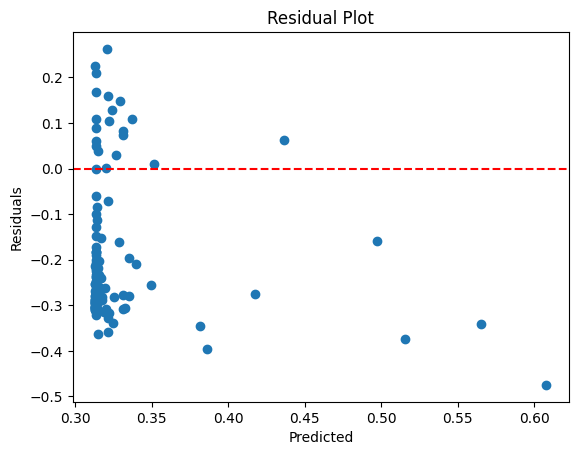

In [29]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_reg
plt.scatter(y_pred_reg, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [35]:

from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train_scaled, y_train)
print(model.score(X_test_scaled, y_test))

-5.6795406150267


In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
print(model.score(X_test_scaled, y_test))

-6.567557054247015
